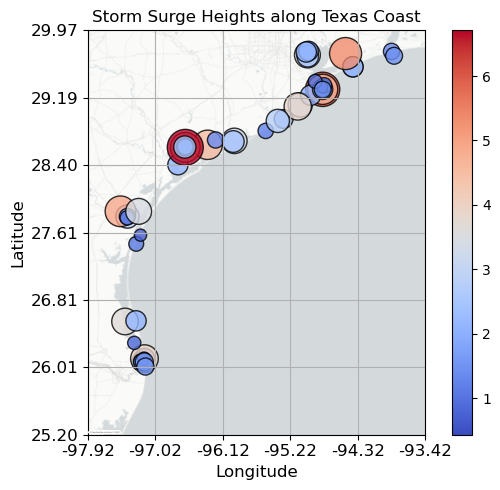

In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

# Step 1: Read data
file_path = r"D:\Phd Research\Excel\surgeheight analysis.xlsx"
sheet_name = "TX Coast"
df = pd.read_excel(file_path, sheet_name=sheet_name)

df_clean = df[['Year', 'Storm Name', 'Storm Dates', 'State', 'Location', 'Lat', 'Lon', 'Storm_Tide_m']]
df_clean = df_clean.dropna(how='all')

# Step 2: GeoDataFrame in WGS84
gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean['Lon'], df_clean['Lat']),
    crs="EPSG:4326"
)

# Save latlon copy
gdf_latlon = gdf.copy()

# Step 3: Reproject for basemap
gdf_merc = gdf.to_crs(epsg=3857)

# Step 4: Plotting
fig, ax = plt.subplots(figsize=(6,5 ))
                            
# Plot points
gdf_merc.plot(
    ax=ax,
    column='Storm_Tide_m',
    cmap='coolwarm',
    markersize=gdf_merc['Storm_Tide_m']*100,
    legend=True,
    alpha=0.8,
    edgecolor='k'
)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    crs=gdf_merc.crs.to_string(),
    zoom=7,   # Slightly zoomed-out view
    attribution_size=0
)

# Set xlim and ylim with **small buffer**
xmin, ymin, xmax, ymax = gdf_merc.total_bounds
buffer = 10000  # 10 km buffer only
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Transformer for axis labels
transformer = Transformer.from_crs(3857, 4326, always_xy=True)

# Axis ticks conversion
xticks = ax.get_xticks()
yticks = ax.get_yticks()

xticks_lon = [transformer.transform(x, ymin)[0] for x in xticks]
yticks_lat = [transformer.transform(xmin, y)[1] for y in yticks]

ax.set_xticks(xticks)
ax.set_xticklabels([f"{lon:.2f}" for lon in xticks_lon], fontsize=12)

ax.set_yticks(yticks)
ax.set_yticklabels([f"{lat:.2f}" for lat in yticks_lat], fontsize=12)

# Labels and title
ax.set_xlabel("Longitude",fontsize=12)
ax.set_ylabel("Latitude",fontsize=12)
ax.set_title("Storm Surge Heights along Texas Coast", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()


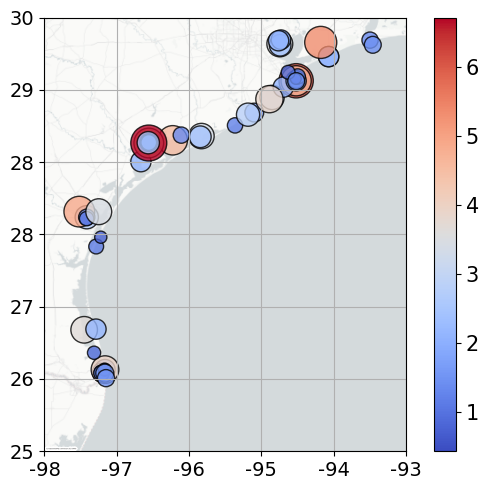

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
from matplotlib_scalebar.scalebar import ScaleBar  # Needed only if you add scale later

# Step 1: Read data
file_path = r"D:\Phd Research\Excel\surgeheight analysis.xlsx"
sheet_name = "TX Coast"
df = pd.read_excel(file_path, sheet_name=sheet_name)

df_clean = df[['Year', 'Storm Name', 'Storm Dates', 'State', 'Location', 'Lat', 'Lon', 'Storm_Tide_m']]
df_clean = df_clean.dropna(how='all')

# Step 2: GeoDataFrame in WGS84
gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean['Lon'], df_clean['Lat']),
    crs="EPSG:4326"
)

# Save latlon copy
gdf_latlon = gdf.copy()

# Step 3: Reproject for basemap
gdf_merc = gdf.to_crs(epsg=3857)

# Step 4: Plotting
fig, ax = plt.subplots(figsize=(6, 5))

# Plot points and capture returned plot with colorbar
plot = gdf_merc.plot(
    ax=ax,
    column='Storm_Tide_m',
    cmap='coolwarm',
    markersize=gdf_merc['Storm_Tide_m'] * 100,
    legend=True,
    alpha=0.8,
    edgecolor='k'
)

# Increase colorbar (legend) label size only
cbar = plot.get_figure().axes[-1]
# cbar.set_ylabel("Surge Height (m from MSL)", fontsize=17, rotation=-270, labelpad=15)
cbar.tick_params(labelsize=15)  # ✅ Corrected: increase tick label size

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    crs=gdf_merc.crs.to_string(),
    zoom=7,
    attribution_size=0
)

# Set xlim and ylim with small buffer
xmin, ymin, xmax, ymax = gdf_merc.total_bounds
buffer = 10000  # 10 km buffer only
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Transformer for axis labels
transformer = Transformer.from_crs(3857, 4326, always_xy=True)

# Axis ticks conversion
xticks = ax.get_xticks()
yticks = ax.get_yticks()

xticks_lon = [transformer.transform(x, ymin)[0] for x in xticks]
yticks_lat = [transformer.transform(xmin, y)[1] for y in yticks]

ax.set_xticks(xticks)
ax.set_xticklabels([f"{lon:.0f}" for lon in xticks_lon], fontsize=14)

ax.set_yticks(yticks)
ax.set_yticklabels([f"{lat:.0f}" for lat in yticks_lat], fontsize=14)

# Labels and title
# ax.set_xlabel("Longitude", fontsize=18)
# ax.set_ylabel("Latitude", fontsize=18)
# ax.set_title("Surge Heights along Texas Coast", fontsize=18)

plt.grid(True)
plt.tight_layout()
plt.show()
